# LightGBM Final Model — Pipeline & Saved Model
**Purpose:** Standardized, end-to-end pipeline for loading, preprocessing, training, evaluating, saving, and reloading the winning LightGBM classifier model using the cross-sectionally ranked financial features.

**Sections**
1. Dependencies
2. Imports
3. Configuration
4. Data Loading
5. Preprocessing
6. Feature Engineering (Cross-Sectional Ranking)
7. Train / Val / Test Split
8. Model Training
9. Evaluation
10. Save & Load Model


## 1. Dependencies

In [1]:
#  INSTALL DEPENDENCIES
# Standard library — no install needed:
#   os, pathlib, zipfile, warnings, datetime
#
# Third-party — install via pip:
#   pip install numpy==1.26.4
#   pip install pandas==2.2.2
#   pip install scikit-learn==1.4.2
#   pip install lightgbm==4.3.0
#   pip install matplotlib==3.8.4
#   pip install seaborn==0.13.2
#   pip install yfinance==0.2.40   # only needed for downloading fresh market data
#
# Or install everything at once:
# %pip install numpy==1.26.4 pandas==2.2.2 scikit-learn==1.4.2 lightgbm==4.3.0 matplotlib==3.8.4 seaborn==0.13.2 yfinance==0.2.40

## 2. Imports

In [2]:
# STANDARD LIBRARY
import os
import zipfile
import pickle
import warnings
from pathlib import Path
from datetime import datetime
import numpy as np                     # numpy>=1.26
import pandas as pd                    # pandas>=2.0
import matplotlib.pyplot as plt        # matplotlib>=3.8
import seaborn as sns                  # seaborn>=0.13
%pip install pyarrow
import pyarrow

# LGBM MODEL 
import lightgbm as lgb                 # lightgbm>=4.0
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)                                      # scikit-learn>=1.4

warnings.filterwarnings("ignore")
print(f"numpy={np.__version__}  pandas={pd.__version__}  lightgbm={lgb.__version__}")


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
numpy=2.2.6  pandas=2.3.3  lightgbm=4.6.0


In [3]:
import os, subprocess

REPO_URL = "https://github.com/tongyuguo/HelpHerInvest.git"
REPO_DIR = Path("HelpHerInvest")
data_dir = REPO_DIR / "Data"

def clone_or_pull():
    if (REPO_DIR / ".git").is_dir():
        subprocess.run(["git", "-C", str(REPO_DIR), "pull"])
    else:
        subprocess.run(["git", "clone", REPO_URL])

clone_or_pull()

Already up to date.


## 3. Configuration


In [4]:
# PATHS
DATA_ZIP_PATH   = data_dir / "final_dataset_20260224v2.csv.zip"
DATA_CSV_NAME   = "final_dataset_20260224v2.csv"   # filename inside the zip

ARTIFACTS_DIR   = REPO_DIR / "artifacts"
MODEL_PATH      = ARTIFACTS_DIR / "lgbm_model.pkl"
TRAIN_DATA_PATH = ARTIFACTS_DIR / "train_ranked.parquet"
VAL_DATA_PATH   = ARTIFACTS_DIR / "val_ranked.parquet"
TEST_DATA_PATH  = ARTIFACTS_DIR / "test_ranked.parquet"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# SPLIT FRACTIONS
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15

# TARGET COLUMN
TARGET_COL = "y"           # 1 if fwd_excess > 0
DATE_COL   = "Date"
TICKER_COL = "Ticker"

# COLUMNS TO EXCLUDE FROM FEATURES 
NON_FEATURE_COLS = [DATE_COL, TICKER_COL, "fwd_excess", "fwd_return", "y", "fwd_rank", "target"]

# FEATURE COLUMNS
RANK_COLS = [
    "mom_1m", "mom_3m", "mom_6m", "mom_12m", "mom_12m_ex_1m",
    "rel_3m_spy", "rel_6m_spy", "rel_12m_spy",
    "vol_3m", "vol_6m",
    "drawdown_6m", "drawdown_12m",
    "pct_above_200dma",
]

#  LIGHTGBM HYPERPARAMETERS
LGBM_PARAMS = dict(
    n_estimators  = 1000,
    learning_rate = 0.01,
    max_depth     = 12,
    num_leaves    = 31,
    class_weight  = "balanced",
    random_state  = 42,
)


## 4. Data Loading

In [5]:
def load_data(zip_path: Path, csv_name: str) -> pd.DataFrame:

    with zipfile.ZipFile(zip_path) as z:
        with z.open(csv_name) as f:
            df = pd.read_csv(f)

    df[DATE_COL] = pd.to_datetime(df[DATE_COL])   # ensure datetime dtype
    tickers = df[TICKER_COL].unique()
    print(f"Loaded  : {df.shape[0]} rows  x  {df.shape[1]} cols")
    print(f"Tickers : {len(tickers)}")
    print(f"Date range: {df[DATE_COL].min().date()}  →  {df[DATE_COL].max().date()}")
    return df


def save_data(df: pd.DataFrame, path: Path, fmt: str = "parquet") -> None:
    """
    Save a DataFrame to disk.

    """
    path.parent.mkdir(parents=True, exist_ok=True)
    if fmt == "parquet":
        df.to_parquet(path, index=False)
    elif fmt == "csv":
        df.to_csv(path, index=False)
    elif fmt == "pickle":
        df.to_pickle(path)
    else:
        raise ValueError(f"Unsupported fmt={fmt!r}. Choose parquet | csv | pickle.")
    print(f"Saved  {df.shape} → {path}")


def load_saved_data(path: Path) -> pd.DataFrame:
    """
    Load a previously saved DataFrame.

    """
    ext = path.suffix.lower()
    if ext == ".parquet":
        df = pd.read_parquet(path)
    elif ext == ".csv":
        df = pd.read_csv(path)
    elif ext in (".pkl", ".pickle"):
        df = pd.read_pickle(path)
    else:
        raise ValueError(f"Unknown extension {ext}. Supported: .parquet, .csv, .pkl")
    print(f"Loaded {df.shape} ← {path}")
    return df



df_raw = load_data(DATA_ZIP_PATH, DATA_CSV_NAME)


Loaded  : 302024 rows  x  18 cols
Tickers : 1993
Date range: 2010-02-28  →  2026-02-28


## 5. Preprocessing


Dropped 27,513 rows with NaNs  (302,024 → 274,511)
Class balance  →  positive: 132974  (48.4%)  |  negative: 141537  (51.6%)


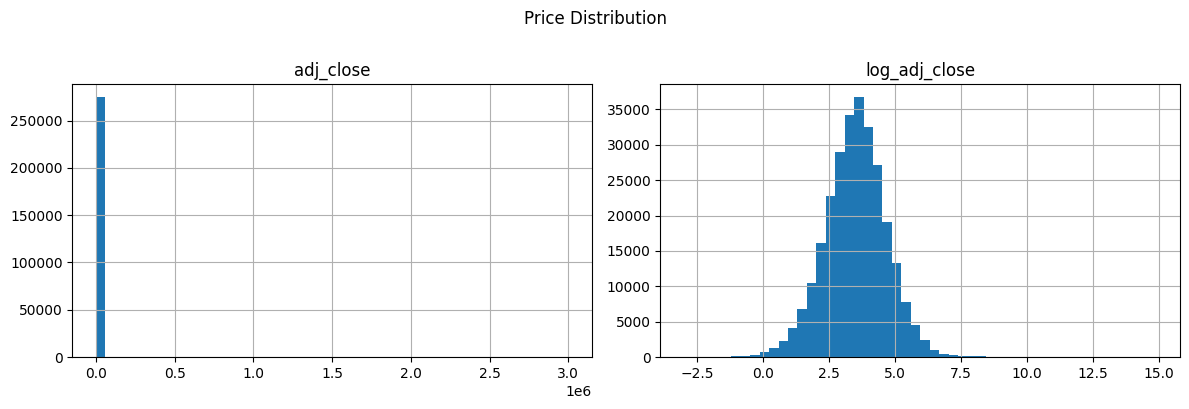

In [6]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Steps:
    --------
    Drop rows with any NULL values
    Create binary target y  (1 = fwd_excess > 0)
    Create log_adj_close feature
    Print class balance
    """
    n_before = len(df)
    df_clean = df.dropna().copy()
    n_after  = len(df_clean)
    print(f"Dropped {n_before - n_after:,} rows with NaNs  ({n_before:,} → {n_after:,})")

    # Binary target
    df_clean["y"] = (df_clean["fwd_excess"] > 0).astype(int)
    pos = df_clean["y"].sum()
    print(f"Class balance  →  positive: {pos}  ({pos/n_after:.1%})  |  negative: {n_after-pos}  ({(n_after-pos)/n_after:.1%})")

    # Log price feature
    df_clean["log_adj_close"] = np.log(df_clean["adj_close"])

    return df_clean



df_clean = preprocess_data(df_raw)

# Adjusted close price and log price distributions
df_clean[["adj_close", "log_adj_close"]].hist(figsize=(12, 4), bins=50)
plt.suptitle("Price Distribution", y=1.01)
plt.tight_layout()
plt.show()


## 6. Feature Engineering — Cross-Sectional Ranking

In [7]:
def apply_cross_sectional_rank(df: pd.DataFrame, rank_cols: list, date_col: str = DATE_COL) -> pd.DataFrame:
    """
    Replace raw feature values with their percentile rank within each date.
    This neutralizes time-series level shifts and makes features comparable
    across periods.
    """
    df_rank = df.copy()
    for col in rank_cols:
        if col not in df_rank.columns:
            print(f"  Warning: column {col!r} not found — skipping.")
            continue
        df_rank[col] = df_rank.groupby(date_col)[col].rank(pct=True)

    # Quintile label for the forward return (0 = worst, 4 = best)
    df_rank["fwd_rank"] = df_rank.groupby(date_col)["fwd_excess"].rank(pct=True)
    df_rank["target"]   = pd.cut(
        df_rank["fwd_rank"],
        bins=[0, .2, .4, .6, .8, 1.0],
        labels=[0, 1, 2, 3, 4],
    )
    return df_rank


def retrieve_features(df: pd.DataFrame, exclude_cols: list = NON_FEATURE_COLS) -> list:
    """
    Return a sorted list of feature column names by excluding known non-feature columns.
    """
    feature_cols = sorted([c for c in df.columns if c not in exclude_cols])
    print(f"Feature count: {len(feature_cols)}")
    return feature_cols



df_rank = apply_cross_sectional_rank(df_clean, RANK_COLS)
FEATURE_COLS = retrieve_features(df_rank)
print("Sample features:", FEATURE_COLS[:10])


Feature count: 15
Sample features: ['adj_close', 'drawdown_12m', 'drawdown_6m', 'log_adj_close', 'mom_12m', 'mom_12m_ex_1m', 'mom_1m', 'mom_3m', 'mom_6m', 'pct_above_200dma']


## 7. Train / Val / Test Split

In [8]:
def time_split(
    df: pd.DataFrame,
    date_col: str  = DATE_COL,
    train_frac: float = TRAIN_FRAC,
    val_frac:   float = VAL_FRAC,
    test_frac:  float = TEST_FRAC,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Chronological train / validation / test split on unique dates.
    No row shuffling — preserves temporal order to avoid look-ahead leakage.
    """
    if abs(train_frac + val_frac + test_frac - 1.0) > 1e-8:
        raise ValueError("Fractions must sum to 1.0")

    unique_dates = df[date_col].drop_duplicates().sort_values().reset_index(drop=True)
    n = len(unique_dates)
    i_train = int(n * train_frac)
    i_val   = int(n * (train_frac + val_frac))

    train_df = df[df[date_col].isin(unique_dates.iloc[:i_train])].copy()
    val_df   = df[df[date_col].isin(unique_dates.iloc[i_train:i_val])].copy()
    test_df  = df[df[date_col].isin(unique_dates.iloc[i_val:])].copy()

    for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
        print(f"{name:5s}: {len(split):>7,} rows  |  "
              f"{split[date_col].min().date()}  →  {split[date_col].max().date()}")
    return train_df, val_df, test_df



train_df, val_df, test_df = time_split(df_rank)

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_val,   y_val   = val_df[FEATURE_COLS],   val_df[TARGET_COL]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[TARGET_COL]

# Save splits for reproducibility and future inference
#save_data(train_df, TRAIN_DATA_PATH)
#save_data(val_df,   VAL_DATA_PATH)
#save_data(test_df,  TEST_DATA_PATH)


Train: 176,701 rows  |  2011-01-31  →  2021-05-31
Val  :  47,488 rows  |  2021-06-30  →  2023-08-31
Test :  50,322 rows  |  2023-09-30  →  2025-11-30


## 8. Model Training

In [9]:
def train_lgbm(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val:   pd.DataFrame,
    y_val:   pd.Series,
    params:  dict = LGBM_PARAMS,
) -> lgb.LGBMClassifier:
    """
    Fit a LightGBM classifier with early stopping on a validation set.
    """
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
    )
    print(f"Training complete — best iteration: {model.best_iteration_}")
    return model



lgb_model = train_lgbm(X_train, y_train, X_val, y_val)


[LightGBM] [Info] Number of positive: 86755, number of negative: 89946
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031427 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 176701, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training complete — best iteration: 0


## 9. Evaluation

── Validation Set ──
              precision    recall  f1-score   support

           0       0.54      0.53      0.53     24830
           1       0.50      0.51      0.50     22658

    accuracy                           0.52     47488
   macro avg       0.52      0.52      0.52     47488
weighted avg       0.52      0.52      0.52     47488

Macro F1:  0.5175
ROC-AUC:   0.5229
── Test Set ──
              precision    recall  f1-score   support

           0       0.54      0.52      0.53     26761
           1       0.48      0.49      0.48     23561

    accuracy                           0.51     50322
   macro avg       0.51      0.51      0.51     50322
weighted avg       0.51      0.51      0.51     50322

Macro F1:  0.5084
ROC-AUC:   0.5133


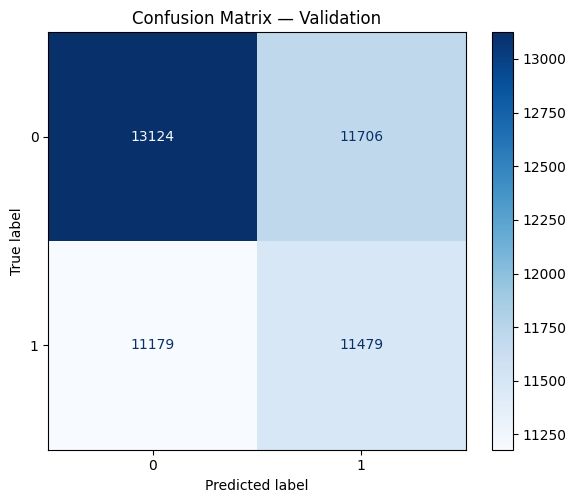

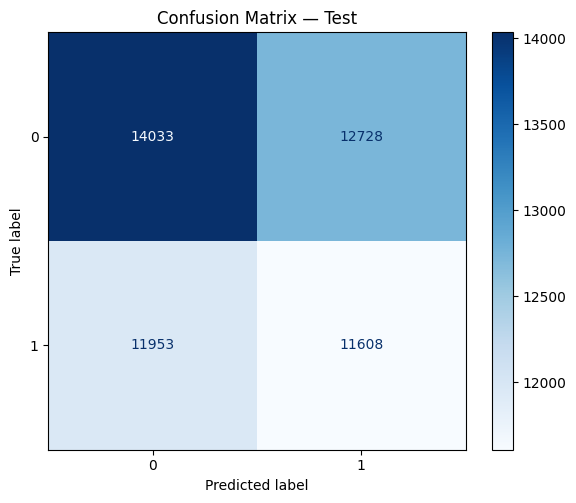

,Pred 0,Pred 1
Actual 0,14033,12728
Actual 1,11953,11608


In [10]:
def evaluate(
    model,
    X: pd.DataFrame,
    y: pd.Series,
    split_name: str = "Set",
) -> dict:
    """
    Print classification metrics and return them as a dict.
    """
    y_pred = model.predict(X)
    probs  = model.predict_proba(X)[:, 1]
    f1     = round(f1_score(y, y_pred, average="macro"), 4)
    auc    = round(roc_auc_score(y, probs, average="macro"), 4)

    print(f"── {split_name} ──")
    print(classification_report(y, y_pred))
    print(f"Macro F1:  {f1}")
    print(f"ROC-AUC:   {auc}")
    return {"f1_macro": f1, "roc_auc": auc}


def plot_confusion_matrix(
    model,
    X: pd.DataFrame,
    y: pd.Series,
    title: str = "Confusion Matrix",
) -> pd.DataFrame:
    """
    Plot and return a confusion matrix DataFrame.
    """
    y_pred = model.predict(X)
    cm     = confusion_matrix(y, y_pred)
    cm_df  = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(
        ax=ax, cmap="Blues", values_format="d"
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return cm_df


val_metrics  = evaluate(lgb_model, X_val,  y_val,  "Validation Set")
test_metrics = evaluate(lgb_model, X_test, y_test, "Test Set")

plot_confusion_matrix(lgb_model, X_val,  y_val,  "Confusion Matrix — Validation")
plot_confusion_matrix(lgb_model, X_test, y_test, "Confusion Matrix — Test")


## 10. Save & Load Model

In [11]:
def save_model(model, path: Path) -> None:
    """
    Serialize the model to disk using pickle.
    """
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(model, f, protocol=pickle.HIGHEST_PROTOCOL)
    size_kb = path.stat().st_size / 1024
    print(f"Model saved  → {path}  ({size_kb:.1f} KB)  |  {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


def load_model(path: Path):
    """
    Load the pickled model from disk.
    """
    with open(path, "rb") as f:
        model = pickle.load(f)
    print(f"Model loaded ← {path}")
    return model


# ── Save the model ───────────────────────────────────────────────────────────────
save_model(lgb_model, MODEL_PATH)

# ── Reload and verify  ───────────────────────────────────────
lgb_model_loaded = load_model(MODEL_PATH)
print("Verification:")
evaluate(lgb_model_loaded, X_val, y_val, "Validation (reloaded model)")


Model saved  → HelpHerInvest/artifacts/lgbm_model.pkl  (3455.5 KB)  |  2026-04-24 02:51:46
Model loaded ← HelpHerInvest/artifacts/lgbm_model.pkl
Verification:
── Validation (reloaded model) ──
              precision    recall  f1-score   support

           0       0.54      0.53      0.53     24830
           1       0.50      0.51      0.50     22658

    accuracy                           0.52     47488
   macro avg       0.52      0.52      0.52     47488
weighted avg       0.52      0.52      0.52     47488

Macro F1:  0.5175
ROC-AUC:   0.5229


{'f1_macro': 0.5175, 'roc_auc': 0.5229}

# NLP

In [12]:
# create unique ticker dataframe 

def create_unique_ticker_df(df):
    if "Ticker" not in df.columns:
        raise ValueError("Column 'Ticker' not found in dataframe.")
    
    unique_ticker = (
        df["Ticker"]
        .dropna()
        .astype(str)
        .str.upper()
        .str.strip()
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
        .to_frame(name="Ticker")
    )
    
    return unique_ticker

unique_ticker = create_unique_ticker_df(df_rank)

print(unique_ticker.head())
print("Number of unique tickers:", len(unique_ticker))

  Ticker
0      A
1     AA
2    AAL
3   AAON
4    AAP
Number of unique tickers: 1913


In [13]:
from pprint import pprint

#API 
from dotenv import load_dotenv
import os
load_dotenv() 

from openai import OpenAI
import pandas as pd
import io
import json

client = OpenAI()

def get_30_unique_tickers(unique_ticker: pd.DataFrame, user_input: str, model: str = "gpt-5-mini") -> pd.DataFrame:

    if "Ticker" not in unique_ticker.columns:
        raise ValueError("unique_ticker must contain a 'Ticker' column.")

    # Clean ticker column
    valid_tickers = (
        unique_ticker["Ticker"]
        .dropna()
        .astype(str)
        .str.upper()
        .str.strip()
        .drop_duplicates()
    )

    valid_ticker_set = set(valid_tickers)

    # Convert dataframe to in-memory CSV
    ticker_buffer = io.BytesIO()
    valid_tickers.to_frame(name="Ticker").to_csv(ticker_buffer, index=False)
    ticker_buffer.seek(0)
    ticker_buffer.name = "unique_ticker.csv"

    # Upload in-memory file
    uploaded_file = client.files.create(file=ticker_buffer, purpose="user_data")

    # Call model
    response = client.responses.create(
        model=model,
        input=[
            {
                "role": "developer",
                "content": [
                    {
                        "type": "input_text",
                        "text": (
                            "You are selecting stock tickers for a downstream model.\n"
                            "You must use the attached CSV file as the only allowed universe of tickers.\n"
                            "Based on the user's interest, return exactly 30 unique ticker symbols.\n"
                            "Rules:\n"
                            "- Only return tickers that exist in the attached file.\n"
                            "- Return exactly 30 unique tickers.\n"
                            "- Do not include explanations.\n"
                            "- Do not include markdown.\n"
                            '- Return valid JSON in this exact format: {"tickers": ["AAPL", "MSFT", "..."]}'
                        )
                    }
                ]
            },
            {
                "role": "user",
                "content": [
                    {"type": "input_file", "file_id": uploaded_file.id},
                    {"type": "input_text", "text": user_input}
                ]
            }
        ]
    )

    # Parse JSON output
    try:
        result = json.loads(response.output_text)
        tickers = result["tickers"]
    except Exception as e:
        raise ValueError(f"Model output was not valid JSON: {response.output_text}") from e

    # Clean + validate output
    cleaned = []
    seen = set()

    for t in tickers:
        t = str(t).upper().strip()
        if t in valid_ticker_set and t not in seen:
            cleaned.append(t)
            seen.add(t)

    if len(cleaned) != 30:
        raise ValueError(
            f"Expected 30 valid unique tickers, but got {len(cleaned)} after validation.\n"
            f"Raw model output: {response.output_text}"
        )

    # Return dataframe
    selected_tickers_df = pd.DataFrame({"Ticker": cleaned})
    return selected_tickers_df

In [14]:
user_input = "I like the fashion industry."

selected_tickers_df = get_30_unique_tickers(unique_ticker, user_input)

print(selected_tickers_df)
print(selected_tickers_df.shape)

   Ticker
0     AEO
1     ANF
2     BKE
3    BURL
4    DECK
5    CROX
6     GIL
7     ELF
8    ETSY
9     GAP
10   AMZN
11   EBAY
12   COST
13    DDS
14     JD
15    DKS
16   BOOT
17     EL
18   COTY
19    BBY
20   BBWI
21    GME
22  GOOGL
23     HD
24    KMX
25    CVS
26    CMG
27    HAS
28   AAPL
29    GPC
(30, 1)


In [15]:
def rank_selected_tickers(
    selected_tickers_df: pd.DataFrame,
    feature_df: pd.DataFrame,
    model,
    feature_cols: list,
    ticker_col: str = "Ticker",
    date_col: str = "Date",
    as_of_date=None,
) -> pd.DataFrame:
    """
    Rank selected tickers using a trained classification model.

    Parameters
    ----------
    selected_tickers_df : pd.DataFrame
        Must contain a 'Ticker' column.
    feature_df : pd.DataFrame
        Feature-ready dataframe containing Ticker, Date, and feature columns.
        Ideally this should be the same schema used to train the model (e.g. df_rank).
    model :
        Trained model with predict_proba().
    feature_cols : list
        Feature columns used during training.
    ticker_col : str
        Name of ticker column.
    date_col : str
        Name of date column.
    as_of_date : str or pd.Timestamp or None
        If provided, only use rows with Date <= as_of_date.
        If None, uses the max available date in feature_df.

    Returns
    -------
    pd.DataFrame
        Ranked dataframe with one row per ticker.
    """
    if ticker_col not in selected_tickers_df.columns:
        raise ValueError(f"selected_tickers_df must contain '{ticker_col}'")

    missing_features = [c for c in feature_cols if c not in feature_df.columns]
    if missing_features:
        raise ValueError(f"feature_df is missing required feature columns: {missing_features}")

    if ticker_col not in feature_df.columns or date_col not in feature_df.columns:
        raise ValueError(f"feature_df must contain '{ticker_col}' and '{date_col}'")

    # Clean tickers in both dfs
    selected = selected_tickers_df.copy()
    selected[ticker_col] = (
        selected[ticker_col].astype(str).str.upper().str.strip()
    )

    df = feature_df.copy()
    df[ticker_col] = df[ticker_col].astype(str).str.upper().str.strip()
    df[date_col] = pd.to_datetime(df[date_col])

    # Determine scoring cutoff date
    if as_of_date is None:
        as_of_date = df[date_col].max()
    else:
        as_of_date = pd.to_datetime(as_of_date)

    # Keep only rows up to the as-of date
    df = df[df[date_col] <= as_of_date].copy()

    # Keep only selected tickers
    selected_set = set(selected[ticker_col])
    df = df[df[ticker_col].isin(selected_set)].copy()

    if df.empty:
        raise ValueError("No matching ticker rows found in feature_df for the selected tickers.")

    # For each ticker, use the latest available row up to as_of_date
    df = df.sort_values([ticker_col, date_col])
    latest_rows = df.groupby(ticker_col, as_index=False).tail(1).copy()

    # Drop rows with missing model features
    before = len(latest_rows)
    latest_rows = latest_rows.dropna(subset=feature_cols).copy()
    dropped = before - len(latest_rows)
    if dropped > 0:
        print(f"Dropped {dropped} selected tickers due to missing feature values.")

    if latest_rows.empty:
        raise ValueError("No selected tickers remain after dropping missing feature rows.")

    # Score with model
    X_score = latest_rows[feature_cols]
    latest_rows["score"] = model.predict_proba(X_score)[:, 1]

    # Rank descending
    ranked = latest_rows.sort_values("score", ascending=False).reset_index(drop=True)
    ranked["rank"] = ranked["score"].rank(method="first", ascending=False).astype(int)

    # Select output columns
    output_cols = [ticker_col, date_col, "score", "rank"]
    return ranked[output_cols]

In [16]:
ranked_tickers_df = rank_selected_tickers(
    selected_tickers_df=selected_tickers_df,
    feature_df=df_rank,
    model=lgb_model,
    feature_cols=FEATURE_COLS,
    ticker_col="Ticker",
    date_col="Date",
    as_of_date=None,   # uses latest available date
)

print(ranked_tickers_df.head(30))

   Ticker       Date     score  rank
0    BOOT 2025-11-30  0.557690     1
1     DDS 2025-11-30  0.529608     2
2    COTY 2025-11-30  0.518596     3
3      EL 2025-11-30  0.514593     4
4     GPC 2025-11-30  0.510827     5
5    BURL 2025-11-30  0.508129     6
6    AAPL 2025-11-30  0.505186     7
7    BBWI 2025-11-30  0.504980     8
8      JD 2025-11-30  0.502736     9
9    EBAY 2025-11-30  0.502192    10
10   AMZN 2025-11-30  0.501392    11
11    GME 2025-11-30  0.498044    12
12    BBY 2025-11-30  0.497532    13
13    DKS 2025-11-30  0.496976    14
14   ETSY 2025-11-30  0.496856    15
15    ELF 2025-11-30  0.496563    16
16   CROX 2025-11-30  0.496174    17
17    GIL 2025-11-30  0.494399    18
18    AEO 2025-11-30  0.490068    19
19    KMX 2025-11-30  0.488352    20
20    BKE 2025-11-30  0.488200    21
21    GAP 2025-11-30  0.484574    22
22    HAS 2025-11-30  0.484467    23
23     HD 2025-11-30  0.481031    24
24    CVS 2025-11-30  0.479985    25
25    CMG 2025-11-30  0.475766    26
2